# **HEALTHCARE ANALYTICS: DOCTOR VISITS**

## VOIS TIRTC Data Analytics Project

**Domain:** Healthcare & Medical Analytics  

**Project Theme:** Healthcare Utilization and Doctor Visits Performance Analysis

**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn, SciPy, Scikit-learn

**Made By:** Pragya Srivastava (STU68639e54e89091751359060)

---

### PROJECT GOAL
To investigate how patient healthcare utilization—specifically doctor visits—varies across demographic, socioeconomic, and health status indicators, and to identify meaningful patterns, trends, relationships, and differences in the healthcare dataset.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/1776250375-P2-Healthcare Analytics for Doctor Visits (1).csv")

In [ ]:
#top 5 rows
df.head()

,Unnamed: 0,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
0,1,1,female,0.19,0.55,1,4,1,yes,no,no,no,no
1,2,1,female,0.19,0.45,1,2,1,yes,no,no,no,no
2,3,1,male,0.19,0.90,3,0,0,no,no,no,no,no
3,4,1,male,0.19,0.15,1,0,0,no,no,no,no,no
4,5,1,male,0.19,0.45,2,5,1,no,no,no,yes,no


In [ ]:
#last 5 rows
df.tail()

,Unnamed: 0,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
5185,5186,0,female,0.22,0.55,0,0,0,no,no,no,no,no
5186,5187,0,male,0.27,1.30,0,0,1,no,no,no,no,no
5187,5188,0,female,0.37,0.25,1,0,1,no,no,yes,no,no
5188,5189,0,female,0.52,0.65,0,0,0,no,no,no,no,no
5189,5190,0,male,0.72,0.25,0,0,0,no,no,yes,no,no


In [ ]:
df.shape

(5190, 13)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5190 entries, 0 to 5189
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  5190 non-null   int64  
 1   visits      5190 non-null   int64  
 2   gender      5190 non-null   object 
 3   age         5190 non-null   float64
 4   income      5190 non-null   float64
 5   illness     5190 non-null   int64  
 6   reduced     5190 non-null   int64  
 7   health      5190 non-null   int64  
 8   private     5190 non-null   object 
 9   freepoor    5190 non-null   object 
 10  freerepat   5190 non-null   object 
 11  nchronic    5190 non-null   object 
 12  lchronic    5190 non-null   object 
dtypes: float64(2), int64(5), object(6)
memory usage: 527.2+ KB


In [ ]:
#stastical inforamation of the dataset
df.describe()

,Unnamed: 0,visits,age,income,illness,reduced,health
count,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000
mean,2595.500000,0.301734,0.406385,0.583160,1.431985,0.861850,1.217534
std,1498.368279,0.798134,0.204782,0.368907,1.384152,2.887628,2.124266
min,1.000000,0.000000,0.190000,0.000000,0.000000,0.000000,0.000000
25%,1298.250000,0.000000,0.220000,0.250000,0.000000,0.000000,0.000000
50%,2595.500000,0.000000,0.320000,0.550000,1.000000,0.000000,0.000000
75%,3892.750000,0.000000,0.620000,0.900000,2.000000,0.000000,2.000000
max,5190.000000,9.000000,0.720000,1.500000,5.000000,14.000000,12.000000


In [ ]:
#Checking the null values
df.isnull().sum()

,0
Unnamed: 0,0
visits,0
gender,0
age,0
income,0
illness,0
reduced,0
health,0
private,0
freepoor,0


### Univariate Analysis: Gender Distribution

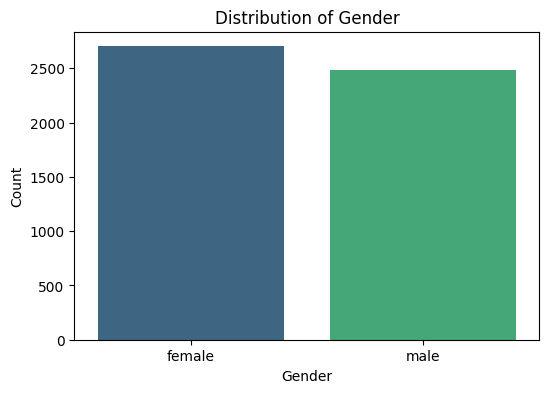

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x='gender', data=df, palette='viridis', hue='gender', legend=False)
plt.title('Distribution of Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

### Univariate Analysis: Age Distribution

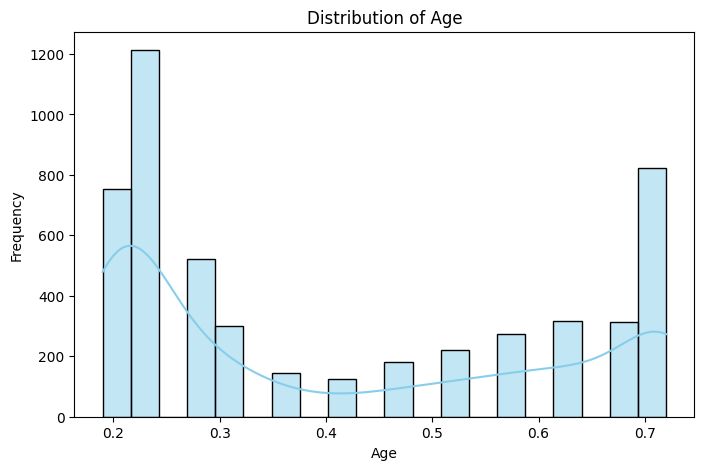

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df['age'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

### Univariate Analysis: Doctor Visits Distribution

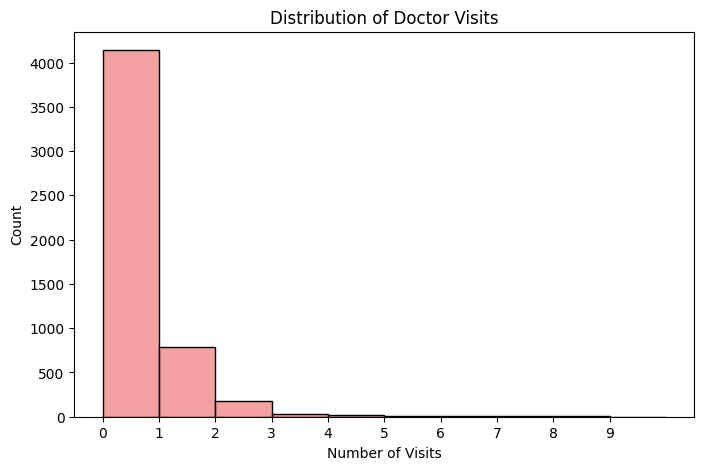

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df['visits'], bins=range(int(df['visits'].max()) + 2), kde=False, color='lightcoral', stat='count')
plt.title('Distribution of Doctor Visits')
plt.xlabel('Number of Visits')
plt.ylabel('Count')
plt.xticks(range(int(df['visits'].max()) + 1))
plt.show()

,gender,count,mean,median
0,female,2702,0.361954,0.0
1,male,2488,0.236334,0.0


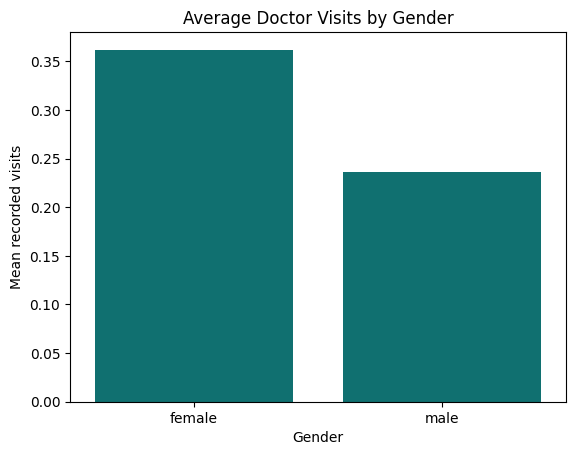

In [ ]:
gender_analysis = (
    df.groupby("gender")["visits"]
      .agg(["count", "mean", "median"])
      .reset_index()
)

display(gender_analysis)

sns.barplot(
    data=gender_analysis,
    x="gender",
    y="mean",
    color="teal"
)

plt.title("Average Doctor Visits by Gender")
plt.xlabel("Gender")
plt.ylabel("Mean recorded visits")
plt.show()

,illness,count,mean
0,0,1554,0.078507
1,1,1638,0.295482
2,2,946,0.403805
3,3,542,0.420664
4,4,274,0.576642
5,5,236,0.813559


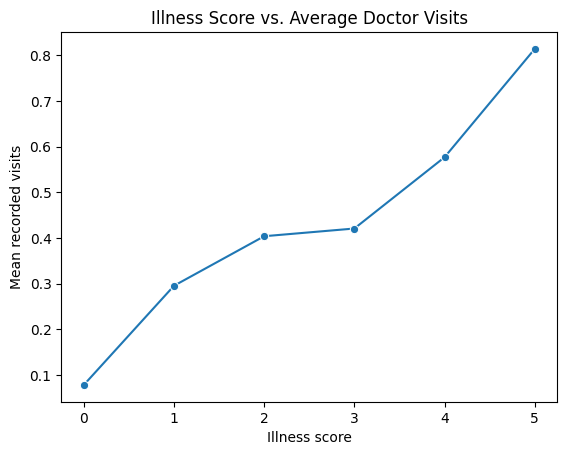

In [15]:
illness_analysis = (
    df.groupby("illness")["visits"]
      .agg(["count", "mean"])
      .reset_index()
)

display(illness_analysis)

sns.lineplot(
    data=illness_analysis,
    x="illness",
    y="mean",
    marker="o"
)

plt.title("Illness Score vs. Average Doctor Visits")
plt.xlabel("Illness score")
plt.ylabel("Mean recorded visits")
plt.show()

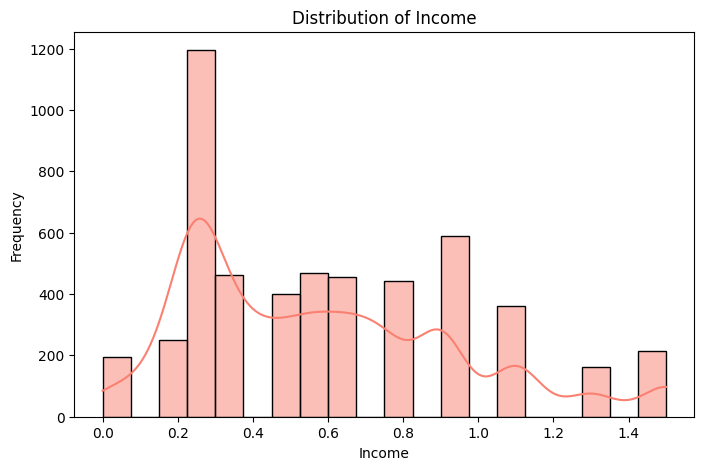

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('/content/1776250375-P2-Healthcare Analytics for Doctor Visits.csv')

# Univariate Analysis: Income Distribution
plt.figure(figsize=(8, 5))
sns.histplot(df['income'], bins=20, kde=True, color='salmon')
plt.title('Distribution of Income')
plt.xlabel('Income')
plt.ylabel('Frequency')
plt.show()

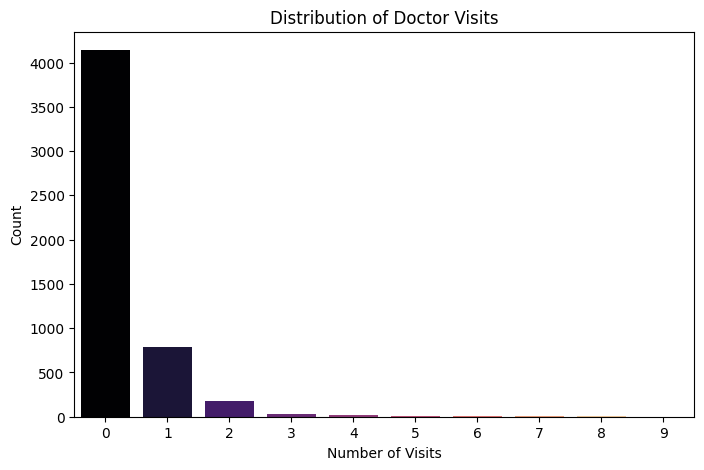

In [ ]:
# Univariate Analysis: Number of Visits Distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='visits', data=df, palette='magma', hue='visits', legend=False)
plt.title('Distribution of Doctor Visits')
plt.xlabel('Number of Visits')
plt.ylabel('Count')
plt.show()

/tmp/ipykernel_553/1945508358.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='private', y='income', data=df, palette='Set2')


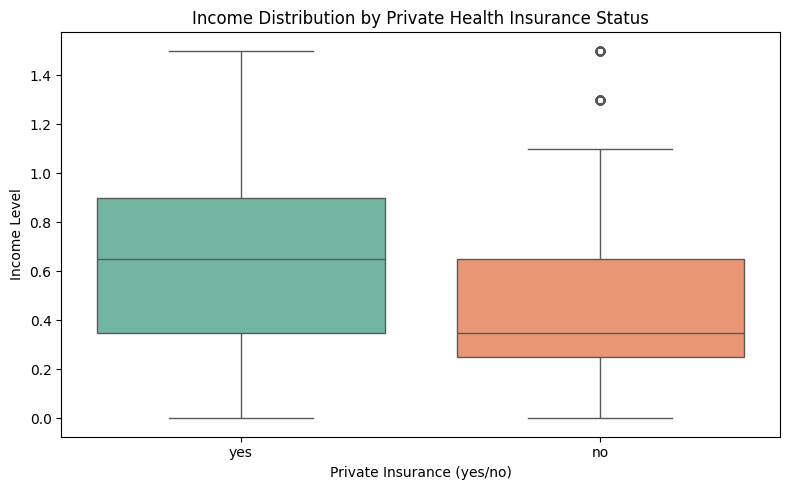

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='private', y='income', data=df, palette='Set2')
plt.title('Income Distribution by Private Health Insurance Status')
plt.xlabel('Private Insurance (yes/no)')
plt.ylabel('Income Level')
plt.tight_layout()
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

### Multivariate Analysis: Visits by Gender

/tmp/ipykernel_1980/3811104772.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='gender', y='visits', data=df, palette='pastel')


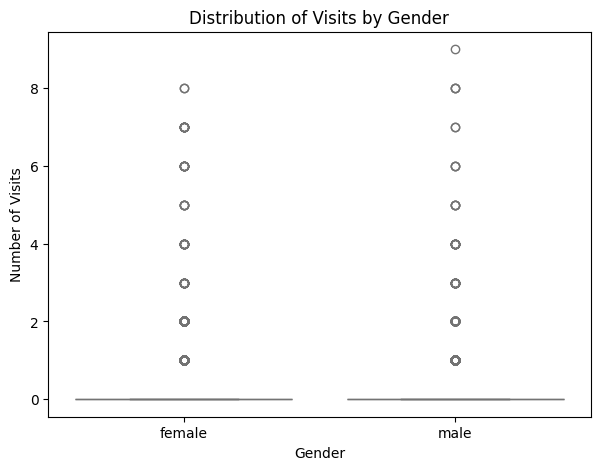

In [ ]:
plt.figure(figsize=(7, 5))
sns.boxplot(x='gender', y='visits', data=df, palette='pastel', hue='gender', legend=False)
plt.title('Distribution of Visits by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Visits')
plt.show()

### Multivariate Analysis: Age, Visits, and Gender

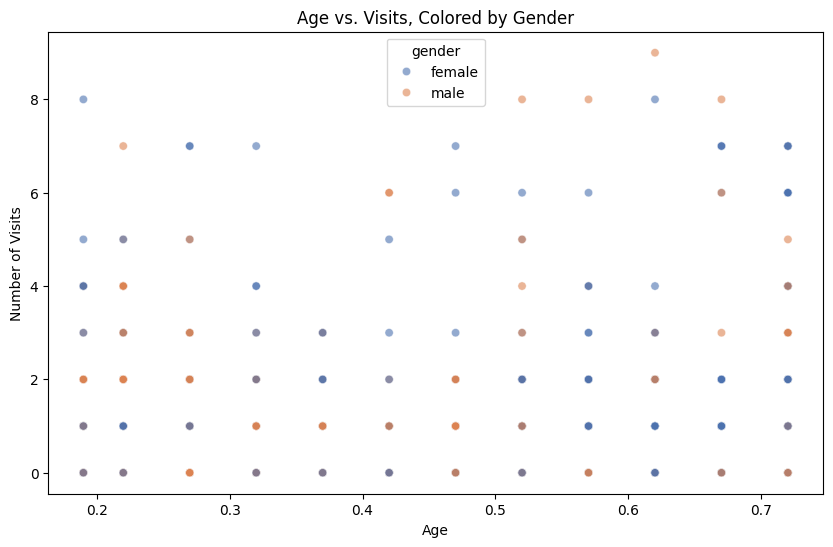

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age', y='visits', hue='gender', data=df, palette='deep', alpha=0.6)
plt.title('Age vs. Visits, Colored by Gender')
plt.xlabel('Age')
plt.ylabel('Number of Visits')
plt.show()

/tmp/ipykernel_553/2503694856.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='visits', y='age', data=df, palette='muted', inner='quartile')


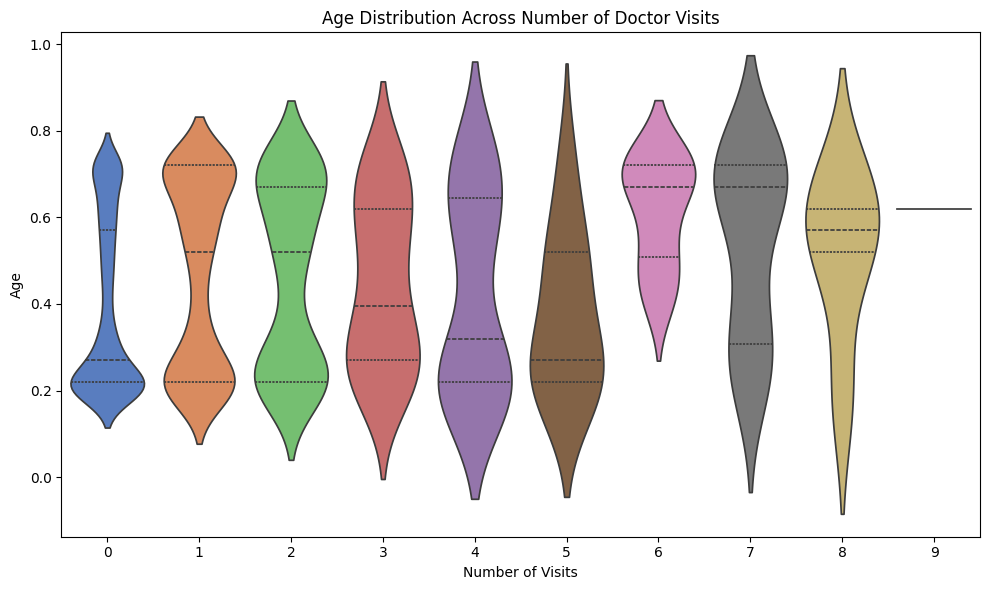

In [ ]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='visits', y='age', data=df, palette='muted', inner='quartile')
plt.title('Age Distribution Across Number of Doctor Visits')
plt.xlabel('Number of Visits')
plt.ylabel('Age')
plt.tight_layout()
plt.show()

/tmp/ipykernel_553/334091354.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='nchronic', y='visits', data=df, palette='magma', errorbar=None)


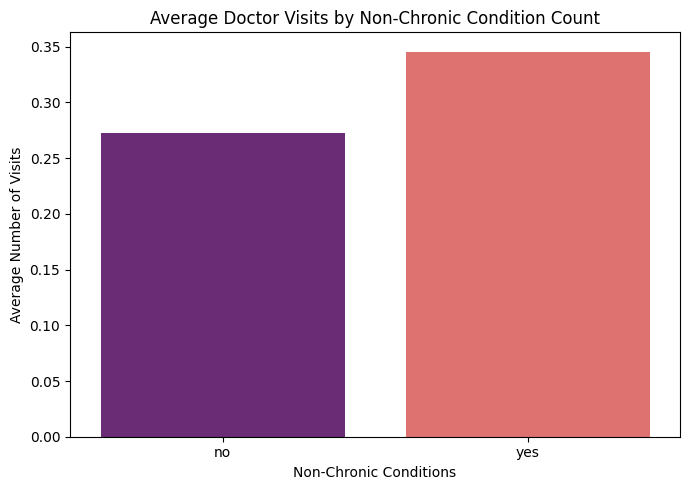

In [ ]:
plt.figure(figsize=(7, 5))
sns.barplot(x='nchronic', y='visits', data=df, palette='magma', errorbar=None)
plt.title('Average Doctor Visits by Non-Chronic Condition Count')
plt.xlabel('Non-Chronic Conditions')
plt.ylabel('Average Number of Visits')
plt.tight_layout()
plt.show()

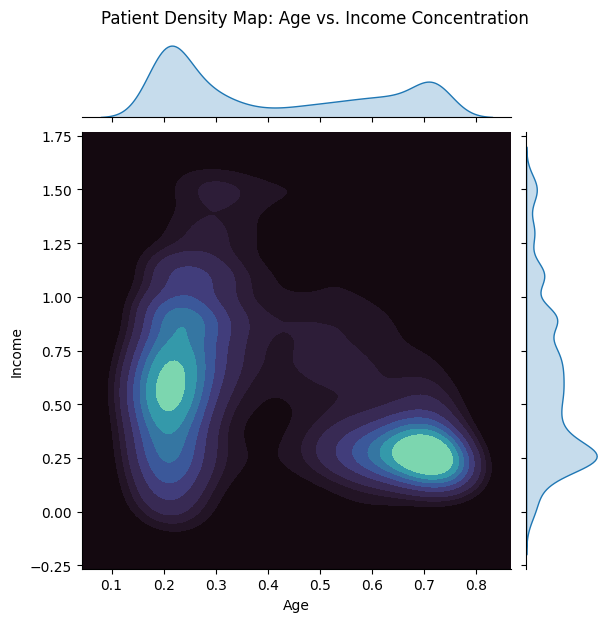

In [ ]:
g = sns.jointplot(
    data=df,
    x="age",
    y="income",
    kind="kde",
    cmap="mako",
    fill=True,
    thresh=0,
    levels=10
)
g.fig.suptitle("Patient Density Map: Age vs. Income Concentration", y=1.03)
g.set_axis_labels("Age", "Income")
plt.show()

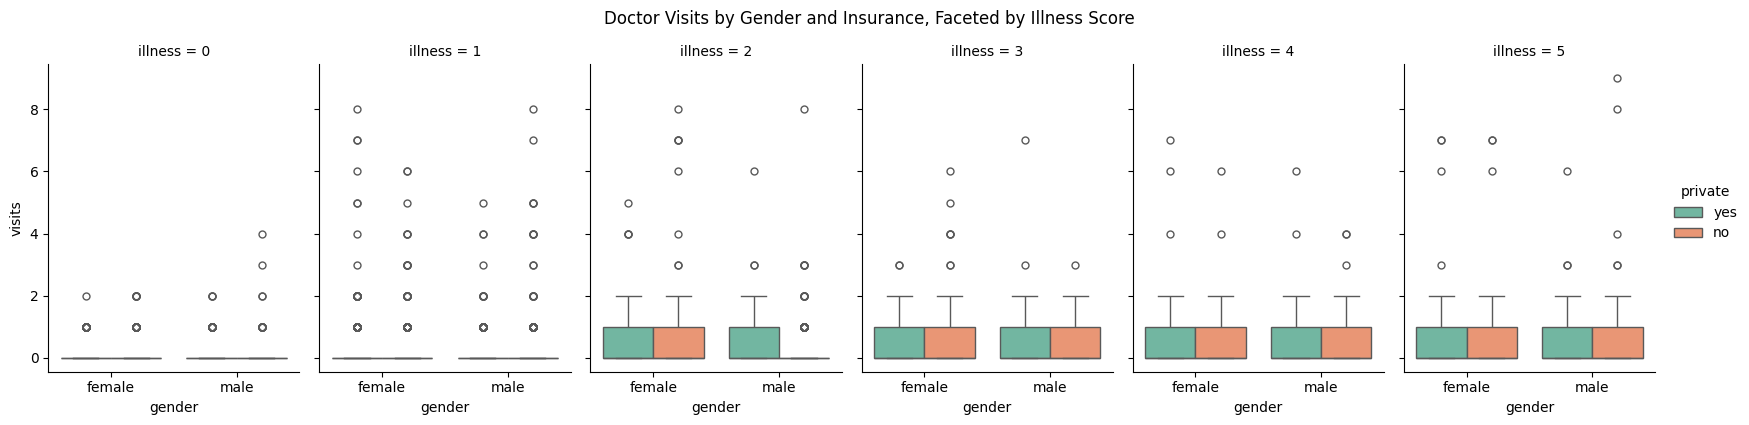

In [ ]:
g = sns.catplot(
    data=df,
    x="gender",
    y="visits",
    hue="private",
    col="illness",
    kind="box",
    palette="Set2",
    height=4,
    aspect=0.7
)
g.fig.suptitle("Doctor Visits by Gender and Insurance, Faceted by Illness Score", y=1.05)
plt.show()

# **SUMMARY OR CONCLUSION**

/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 58.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 56.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 33.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 28.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 11.4% of the points cannot be plac

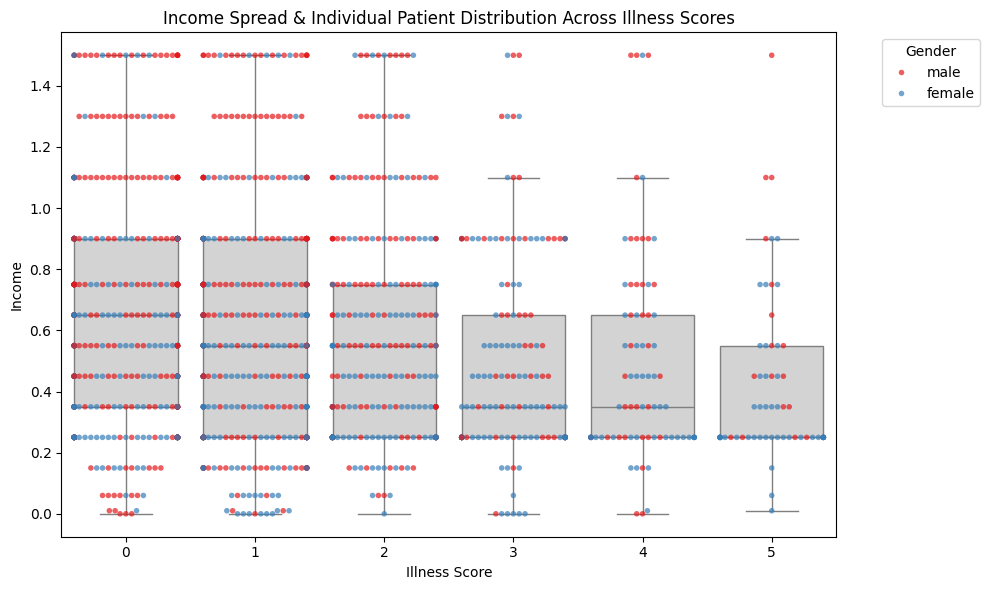

In [ ]:
plt.figure(figsize=(10, 6))
# Using a sampled subset if your dataframe is huge (>3000 rows) for performance
df_sample = df.sample(n=min(len(df), 1500), random_state=42)

sns.boxplot(x="illness", y="income", data=df_sample, color="lightgray", fliersize=0)
sns.swarmplot(x="illness", y="income", data=df_sample, hue="gender", palette="Set1", alpha=0.7, size=4)

plt.title("Income Spread & Individual Patient Distribution Across Illness Scores")
plt.xlabel("Illness Score")
plt.ylabel("Income")
plt.legend(title="Gender", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

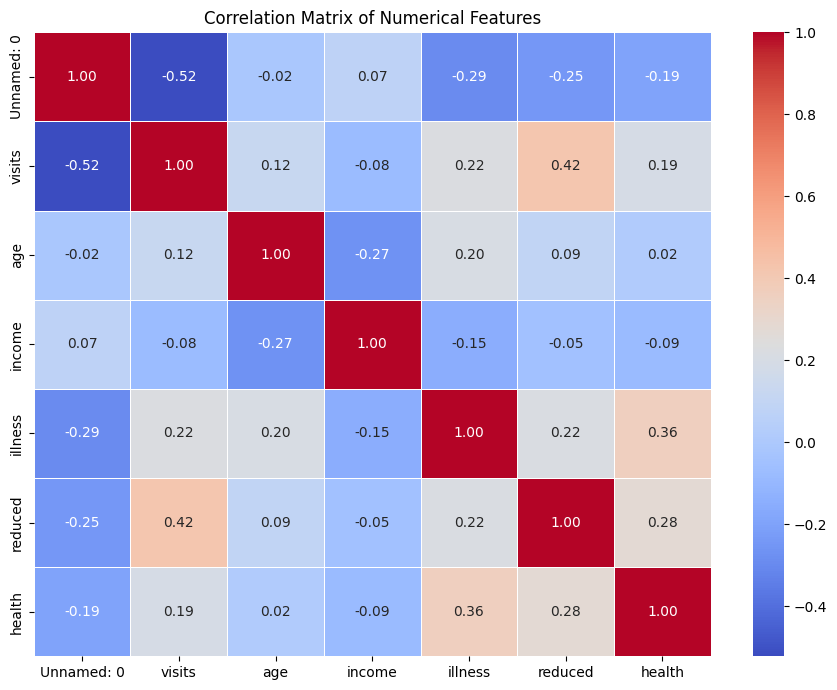

In [ ]:
plt.figure(figsize=(9, 7))
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
correlation_matrix = df[numeric_cols].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, cbar=True)
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

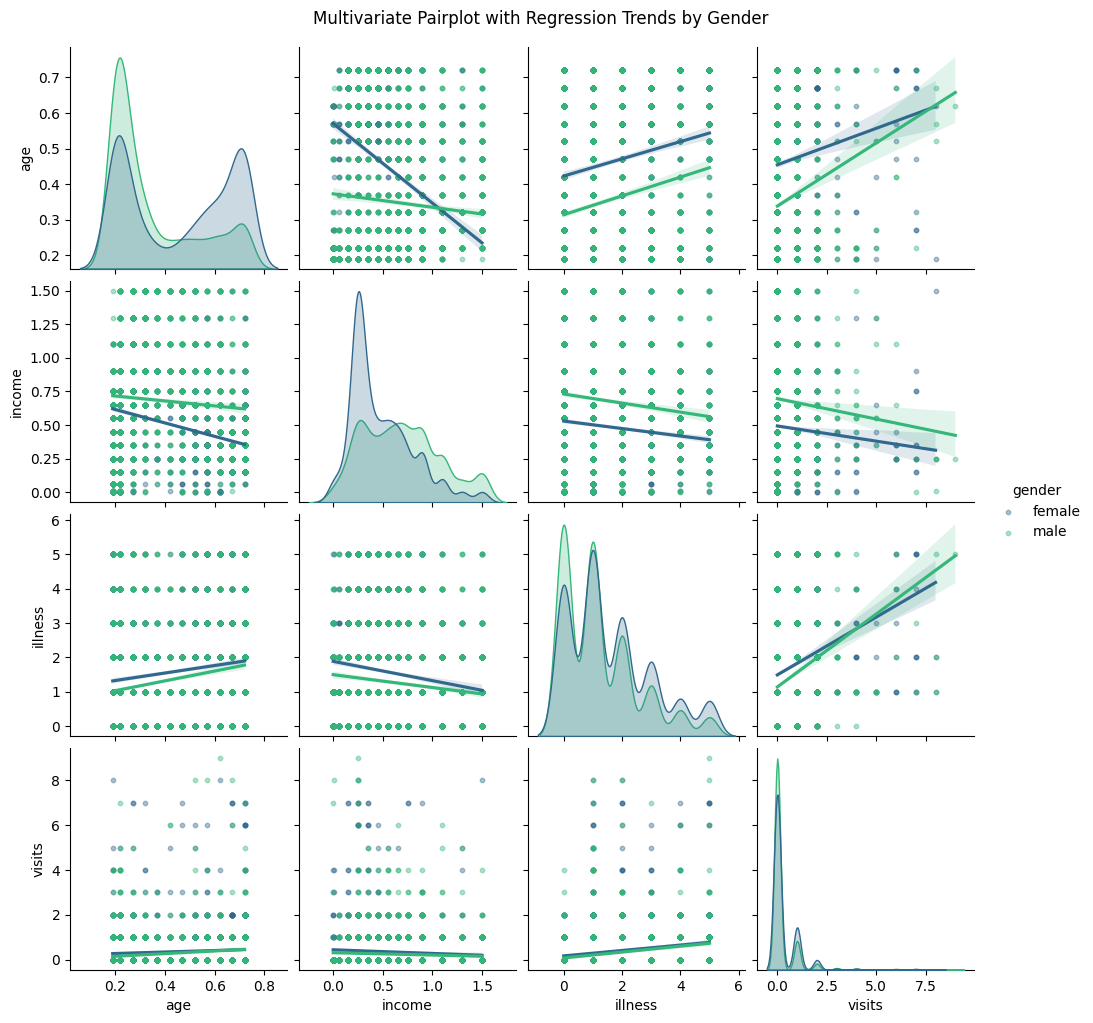

In [ ]:
# Selecting key numerical columns to keep the pairplot clean and readable
cols_to_plot = ['age', 'income', 'illness', 'visits']

g = sns.pairplot(
    df[cols_to_plot + ['gender']].dropna(),
    hue='gender',
    palette='viridis',
    kind='reg',
    diag_kind='kde',
    plot_kws={'scatter_kws': {'alpha': 0.4, 's': 10}}
)
g.fig.suptitle("Multivariate Pairplot with Regression Trends by Gender", y=1.02)
plt.show()

## CONCLUSION

* **Healthcare Utilization Trends:** The exploratory data analysis revealed that doctor visit distributions are heavily right-skewed, with the vast majority of patients recording zero or one visit. However, utilization increases sharply with higher illness scores and the presence of non-chronic conditions.
* **Demographic & Socioeconomic Patterns:** Analysis demonstrated that female patients exhibit a higher average number of doctor visits compared to male patients. Additionally, metrics like income distribution and private health insurance status provide valuable insights into patient healthcare access and disparities.
* **Multivariate Relationships:** Correlation matrices and multivariate pair plots established meaningful relationships among age, income, illness, and visits, offering a robust foundation for future predictive modeling and healthcare resource optimization.